# qBraid-SDK: Visualization

In this notebook, we'll go through some of the main features of the `qbraid.visualization` library.

## Circuit Drawer

First, we utilize the `circuit_drawer` function. This function takes in any type of support quantum circuit, and draws it out in the console.

In [1]:
from qbraid.interface import random_circuit
from qbraid.visualization import circuit_drawer

braket_circuit = random_circuit("braket")
circuit_drawer(braket_circuit)

/Users/tarinihardikar/Desktop/qBraid-software/qbraid-lab-demo/.demo/lib/python3.12/site-packages/bloqade/analog/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


T  : |0 |1|2 |3 |
                 
q0 : ----C-Si----
         |       
q1 : -Si-X-S--Ti-
                 
q2 : -S--X-------

T  : |0 |1|2 |3 |


Let's take this circuit and transpile it to another language to see that it can still be visualized.

In [2]:
from qbraid.transpiler import transpile

cirq_circuit = transpile(braket_circuit, "cirq")
circuit_drawer(cirq_circuit)

0: ──────────@───S^-1──────────
             │
1: ───S^-1───X───S──────T^-1───

2: ───S──────X─────────────────


Additionally, if the library you are working with has options for visualization, those options can be expressed as `kwargs` in `circuit_drawer`. For example:

In [3]:
circuit_drawer(cirq_circuit)

0: ──────────@───S^-1──────────
             │
1: ───S^-1───X───S──────T^-1───

2: ───S──────X─────────────────


## Conversion Graphs

Given a `ConversionGraph`, you can use `plot_conversion_graph` to display the connections between different quantum frameworks.

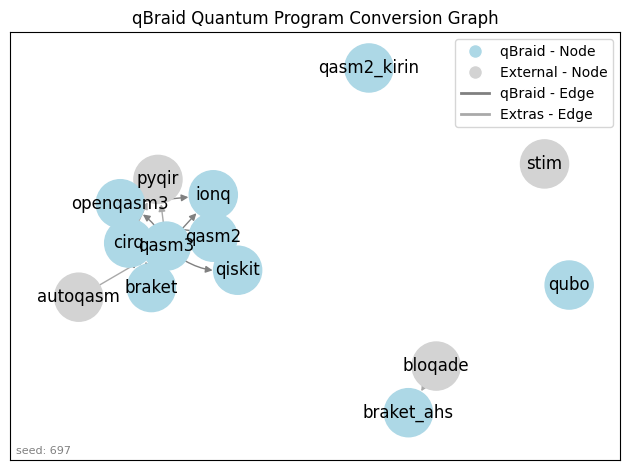

In [4]:
from qbraid.transpiler import ConversionGraph
from qbraid.visualization import plot_conversion_graph

graph = ConversionGraph()
plot_conversion_graph(graph, legend=True)

## Histograms/Distributions

When you have a qBraid quantum job, you can get the measurement counts from it and also plot it using the qBraid-SDK.

In [5]:
from qbraid.runtime import QbraidProvider

provider = QbraidProvider()
device = provider.get_device("aws:aws:sim:sv1")

In [6]:
from braket.circuits import Circuit

circuit = Circuit().h(0).cnot(0, 1)
result = device.run(circuit, shots=1000).result()

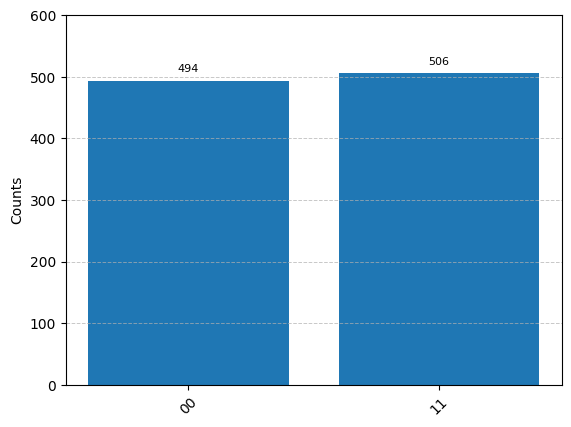

In [7]:
from qbraid.visualization import plot_histogram, plot_distribution

plot_histogram(result.data.measurement_counts)

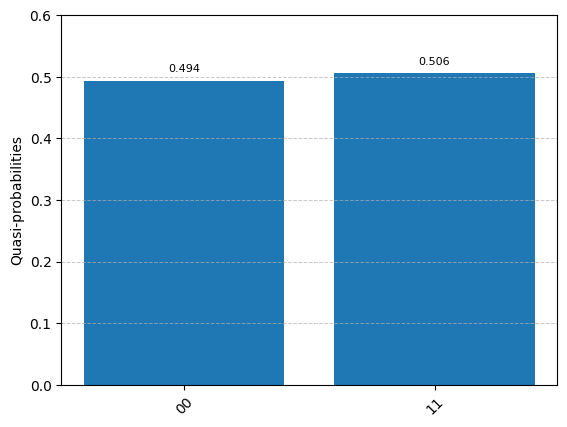

In [8]:
plot_distribution(result.data.measurement_counts)